In [1]:
import re
import requests
from bs4 import BeautifulSoup
import pandas as pd
from urllib.parse import urljoin
import numpy as np

In [2]:
# take the url of the page
page = 1
url = f"https://books.toscrape.com/catalogue/page-{page}.html"

#create the request header
headers={
    "user-Agent":"Mozilla/5.0 (Linux; Android 15; Pixel 9) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/152.0.0.0 Mobile Safari/537.36"
}

#send request 
response=requests.get(url ,headers=headers)
response.status_code

#show content page
response.content



b'\n\n<!DOCTYPE html>\n<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->\n<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->\n<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->\n<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->\n    <head>\n        <title>\n    All products | Books to Scrape - Sandbox\n</title>\n\n        <meta http-equiv="content-type" content="text/html; charset=UTF-8" />\n        <meta name="created" content="24th Jun 2016 09:30" />\n        <meta name="description" content="" />\n        <meta name="viewport" content="width=device-width" />\n        <meta name="robots" content="NOARCHIVE,NOCACHE" />\n\n        <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->\n        <!--[if lt IE 9]>\n        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>\n        <![endif]-->\n\n        \n            <link rel="shortcut icon"

In [3]:
# beautiful soup objecct
bs = BeautifulSoup(response.content, "html.parser")
print(bs)


<!DOCTYPE html>

<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html class="no-js" lang="en-us"> <!--<![endif]-->
<head>
<title>
    All products | Books to Scrape - Sandbox
</title>
<meta content="text/html; charset=utf-8" http-equiv="content-type"/>
<meta content="24th Jun 2016 09:30" name="created"/>
<meta content="" name="description"/>
<meta content="width=device-width" name="viewport"/>
<meta content="NOARCHIVE,NOCACHE" name="robots"/>
<!-- Le HTML5 shim, for IE6-8 support of HTML elements -->
<!--[if lt IE 9]>
        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>
        <![endif]-->
<link href="../static/oscar/favicon.ico" rel="shortcut icon"/>
<link href="../static/oscar/css/styles.css" rel="stylesheet" type="text/css"/>
<link 

In [4]:
# creat list
emt_list=[]

In [5]:
import requests
import time
from bs4 import BeautifulSoup
from urllib.parse import urljoin

# Create session
session = requests.Session()

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/140.0.0.0 Safari/537.36"
}

session.headers.update(headers)

# Store all books
emt_list = []

for page in range(1, 50):

    # URL for each page
    page_url = f"https://books.toscrape.com/catalogue/page-{page}.html"

    try:
        # Request listing page
        response = session.get(page_url, timeout=10)

        # Check status
        response.raise_for_status()

    except requests.RequestException as e:
        print(f"Page {page} failed: {e}")
        continue

    # BeautifulSoup
    bs = BeautifulSoup(response.content, "html.parser")

    # Find all books
    my_books = bs.find_all("article", class_="product_pod")

    print(f"Page {page}: {len(my_books)} books")

    for book in my_books:

        # -------------------------
        # TITLE
        # -------------------------
        title_tag = book.find("h3")

        if not title_tag:
            continue

        title = title_tag.get_text(strip=True)

        if not title:
            continue

        # -------------------------
        # PRICE
        # -------------------------
        price_tag = book.find("p", class_="price_color")

        if price_tag:
            price = price_tag.get_text(strip=True)
        else:
            price = "N/A"

        # -------------------------
        # RATING
        # -------------------------
        rating_tag = book.find("p", class_="star-rating")

        if rating_tag:
            rating = rating_tag.get("class", ["", "N/A"])[1]
        else:
            rating = "N/A"

        # -------------------------
        # AVAILABILITY
        # -------------------------
        availability_tag = book.find(
            "p",
            class_="instock availability"
        )

        if availability_tag:
            availability = availability_tag.get_text(" ", strip=True)
        else:
            availability = "N/A"

        # -------------------------
        # BOOK URL
        # -------------------------
        book_url_tag = book.find("h3").find("a")

        if book_url_tag:
            book_url = urljoin(
                response.url,
                book_url_tag.get("href")
            )
        else:
            book_url = "N/A"

        # -------------------------
        # IMAGE URL
        # -------------------------
        image_tag = book.find("img")

        if image_tag:
            image_url = urljoin(
                response.url,
                image_tag.get("src", "")
            )
        else:
            image_url = "N/A"

        # -------------------------
        # DETAIL PAGE
        # -------------------------
        product_type = "N/A"
        tax = "N/A"
        number_of_reviews = "N/A"

        if book_url != "N/A":

            try:

                detail_response = session.get(
                    book_url,
                    timeout=10
                )

                detail_response.raise_for_status()

                detail_bs = BeautifulSoup(
                    detail_response.content,
                    "html.parser"
                )

                product_table = detail_bs.find(
                    "table",
                    class_="table-striped"
                )

                if product_table:

                    rows = product_table.find_all("tr")

                    # Product Type
                    for row in rows:
                        th = row.find("th")
                        td = row.find("td")

                        if th and td:

                            field = th.get_text(strip=True)
                            value = td.get_text(strip=True)

                            if field == "Product Type":
                                product_type = value

                            elif field == "Tax":
                                tax = value

                            elif field == "Number of reviews":
                                number_of_reviews = value

            except requests.RequestException as e:

                print(f"Detail page failed: {book_url}")
                print(e)

            # Small delay
            time.sleep(0.2)

        # -------------------------
        # STORE DATA
        # -------------------------
        emt_list.append({

            "title": title,
            "price": price,
            "rating": rating,
            "Availability": availability,
            "book_url": book_url,
            "image_url": image_url,
            "product_type": product_type,
            "tax": tax,
            "number_of_reviews": number_of_reviews

        })

    # Delay between pages
    time.sleep(0.5)

Page 1: 20 books
Page 2: 20 books
Page 3: 20 books
Page 4: 20 books
Page 5: 20 books
Page 6: 20 books
Page 7: 20 books
Page 8: 20 books
Page 9: 20 books
Page 10: 20 books
Page 11: 20 books
Page 12: 20 books
Page 13: 20 books
Page 14: 20 books
Page 15: 20 books
Page 16: 20 books
Page 17: 20 books
Page 18: 20 books
Page 19: 20 books
Page 20: 20 books
Page 21: 20 books
Page 22: 20 books
Page 23: 20 books
Page 24: 20 books
Page 25: 20 books
Page 26: 20 books
Page 27: 20 books
Page 28: 20 books
Page 29: 20 books
Page 30: 20 books
Page 31: 20 books
Page 32: 20 books
Page 33: 20 books
Page 34: 20 books
Page 35: 20 books
Page 36: 20 books
Page 37: 20 books
Page 38: 20 books
Page 39: 20 books
Page 40: 20 books
Page 41: 20 books
Page 42: 20 books
Page 43: 20 books
Page 44: 20 books
Page 45: 20 books
Page 46: 20 books
Page 47: 20 books
Page 48: 20 books
Page 49: 20 books


In [6]:
emt_list[0].keys()

dict_keys(['title', 'price', 'rating', 'Availability', 'book_url', 'image_url', 'product_type', 'tax', 'number_of_reviews'])

In [7]:
#display list
for item in emt_list:
    print(f"title: {item['title']}")
    print(f"price:{item['price']}")
    print(f"rating:{item['rating']}")
    print(f"Availability:{item['Availability']}")
    print(f"book_url: {item['book_url']}")
    print(f"image_url : {item['image_url']}")
    print(f"product_type: {item['product_type']}")
    print(f"tax: {item['tax']}")
    print(f"number_of_reviews: {item['number_of_reviews']}")
    print("-"*50)

title: A Light in the ...
price:£51.77
rating:Three
Availability:In stock
book_url: https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html
image_url : https://books.toscrape.com/media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg
product_type: Books
tax: £0.00
number_of_reviews: 0
--------------------------------------------------
title: Tipping the Velvet
price:£53.74
rating:One
Availability:In stock
book_url: https://books.toscrape.com/catalogue/tipping-the-velvet_999/index.html
image_url : https://books.toscrape.com/media/cache/26/0c/260c6ae16bce31c8f8c95daddd9f4a1c.jpg
product_type: Books
tax: £0.00
number_of_reviews: 0
--------------------------------------------------
title: Soumission
price:£50.10
rating:One
Availability:In stock
book_url: https://books.toscrape.com/catalogue/soumission_998/index.html
image_url : https://books.toscrape.com/media/cache/3e/ef/3eef99c9d9adef34639f510662022830.jpg
product_type: Books
tax: £0.00
number_of_reviews: 0
------------

In [8]:
df = pd.DataFrame(emt_list)
df

,title,price,rating,Availability,book_url,image_url,product_type,tax,number_of_reviews
0,A Light in the ...,£51.77,Three,In stock,https://books.toscrape.com/catalogue/a-light-i...,https://books.toscrape.com/media/cache/2c/da/2...,Books,£0.00,0
1,Tipping the Velvet,£53.74,One,In stock,https://books.toscrape.com/catalogue/tipping-t...,https://books.toscrape.com/media/cache/26/0c/2...,Books,£0.00,0
2,Soumission,£50.10,One,In stock,https://books.toscrape.com/catalogue/soumissio...,https://books.toscrape.com/media/cache/3e/ef/3...,Books,£0.00,0
3,Sharp Objects,£47.82,Four,In stock,https://books.toscrape.com/catalogue/sharp-obj...,https://books.toscrape.com/media/cache/32/51/3...,Books,£0.00,0
4,Sapiens: A Brief History ...,£54.23,Five,In stock,https://books.toscrape.com/catalogue/sapiens-a...,https://books.toscrape.com/media/cache/be/a5/b...,Books,£0.00,0
...,...,...,...,...,...,...,...,...,...
975,Icing (Aces Hockey #2),£40.44,Four,In stock,https://books.toscrape.com/catalogue/icing-ace...,https://books.toscrape.com/media/cache/8d/1e/8...,Books,£0.00,0
976,"Hawkeye, Vol. 1: My ...",£45.24,Three,In stock,https://books.toscrape.com/catalogue/hawkeye-v...,https://books.toscrape.com/media/cache/16/46/1...,Books,£0.00,0
977,Having the Barbarian's Baby ...,£34.96,Four,In stock,https://books.toscrape.com/catalogue/having-th...,https://books.toscrape.com/media/cache/f4/83/f...,Books,£0.00,0
978,"Giant Days, Vol. 1 ...",£56.76,Four,In stock,https://books.toscrape.com/catalogue/giant-day...,https://books.toscrape.com/media/cache/35/0b/3...,Books,£0.00,0


In [9]:
# convert all columns into title case
df.columns=df.columns.str.title()
print("df.columns")
print("-"*50)
# remove space
df.columns=df.columns.str.strip()
print(df.columns)

df.columns
--------------------------------------------------
Index(['Title', 'Price', 'Rating', 'Availability', 'Book_Url', 'Image_Url',
       'Product_Type', 'Tax', 'Number_Of_Reviews'],
      dtype='str')


In [10]:
# check missing value
print("missing value:",df.isna().sum())
print("-"*50)

# check duplicated
print("duplicated:",df.duplicated().sum())

# remove symbol




missing value: Title                0
Price                0
Rating               0
Availability         0
Book_Url             0
Image_Url            0
Product_Type         0
Tax                  0
Number_Of_Reviews    0
dtype: int64
--------------------------------------------------
duplicated: 0


In [11]:
# check title columns
print("missing value:",df['Title'].isna().sum())
print("-"*50)

# remove white space
df['Title']=df['Title'].str.strip()
print(df['Title'])

# check duplicated
print("duplicated:",df['Title'].duplicated().sum())
#count duplicated
print("count duplicated:",df['Title'].duplicated().value_counts())
print("-"*50)

# check unique value
#print("unique:",df['Title'].unique())

missing value: 0
--------------------------------------------------
0                   A Light in the ...
1                   Tipping the Velvet
2                           Soumission
3                        Sharp Objects
4         Sapiens: A Brief History ...
                    ...               
975             Icing (Aces Hockey #2)
976            Hawkeye, Vol. 1: My ...
977    Having the Barbarian's Baby ...
978             Giant Days, Vol. 1 ...
979          Fruits Basket, Vol. 1 ...
Name: Title, Length: 980, dtype: str
duplicated: 8
count duplicated: Title
False    972
True       8
Name: count, dtype: int64
--------------------------------------------------


In [12]:
# check Price columns
print("missing value:",df['Price'].isna().sum())
print("-"*50)

# check datatype
print("data type:",df['Price'].dtype)
print("-"*50)

# remove symbol
df['Price']=df['Price'].str.replace("£","",regex=False)
print(df['Price'])

# check duplicated
print("duplicated:",df['Price'].duplicated().sum())

missing value: 0
--------------------------------------------------
data type: str
--------------------------------------------------
0      51.77
1      53.74
2      50.10
3      47.82
4      54.23
       ...  
975    40.44
976    45.24
977    34.96
978    56.76
979    40.28
Name: Price, Length: 980, dtype: str
duplicated: 93


In [13]:
print("data type:",df['Price'].dtype)
print("-"*50)

# check unique
#print("unique:",df['Price'].unique())

# replace symbol
df['Price']=pd.to_numeric(df['Price'],errors="coerce")
print(df['Price'])

data type: str
--------------------------------------------------
0      51.77
1      53.74
2      50.10
3      47.82
4      54.23
       ...  
975    40.44
976    45.24
977    34.96
978    56.76
979    40.28
Name: Price, Length: 980, dtype: float64


In [14]:
print("data type:",df['Price'].dtype)
print("-"*50)

# chenge columns name
df.rename(columns={"Price":"Price(£)"},inplace=True)


data type: float64
--------------------------------------------------


In [15]:
# check Rating columns name
print("missing value:",df['Rating'].isna().sum())

# convert them number
df['Rating']=df['Rating'].replace({
    "One":1,
    "Two":2,
    "Three":3,
    "Four":4,
    "Five":5
})
df['Rating']

# check rating outlier
print("outlier:",(df['Rating'] > 5).sum())
print("-"*50)

# check unique
print("unique:",df['Rating'].unique())

missing value: 0
outlier: 0
--------------------------------------------------
unique: [3 1 4 5 2]


In [16]:
df.columns

Index(['Title', 'Price(£)', 'Rating', 'Availability', 'Book_Url', 'Image_Url',
       'Product_Type', 'Tax', 'Number_Of_Reviews'],
      dtype='str')

In [17]:
# check Availability columns
print("missing value:",df['Availability'].isna().sum())
print("-"*50)

# check unique value
print("unique:",df['Availability'].unique())

missing value: 0
--------------------------------------------------
unique: <StringArray>
['In stock']
Length: 1, dtype: str


In [18]:
# check Book_Url columns
print("missing value:",df['Book_Url'].isna().sum())
print("-"*50)

# check duplicated
print("duplicated:",df['Book_Url'].duplicated().sum())



missing value: 0
--------------------------------------------------
duplicated: 0


In [19]:
# check Image_Url
print("missing value:",df['Image_Url'].isna().sum())
print("-"*50)

# check duplicated
print("duplicated:",df['Image_Url'].duplicated().sum())

missing value: 0
--------------------------------------------------
duplicated: 0


In [20]:
# check Product_Type columns
print("missing value:",df['Product_Type'].isna().sum())
print("-"*50)

# check unique value
print("unique:",df['Product_Type'].unique())

missing value: 0
--------------------------------------------------
unique: <StringArray>
['Books']
Length: 1, dtype: str


In [21]:
# check Tax
print("missing value:",df['Tax'].isna().sum())
print("-"*50)

# rename columns
df=df.rename(columns={"Tax":"Tax(£)"})
print(df)


missing value: 0
--------------------------------------------------
                               Title  Price(£) Rating Availability  \
0                 A Light in the ...     51.77      3     In stock   
1                 Tipping the Velvet     53.74      1     In stock   
2                         Soumission     50.10      1     In stock   
3                      Sharp Objects     47.82      4     In stock   
4       Sapiens: A Brief History ...     54.23      5     In stock   
..                               ...       ...    ...          ...   
975           Icing (Aces Hockey #2)     40.44      4     In stock   
976          Hawkeye, Vol. 1: My ...     45.24      3     In stock   
977  Having the Barbarian's Baby ...     34.96      4     In stock   
978           Giant Days, Vol. 1 ...     56.76      4     In stock   
979        Fruits Basket, Vol. 1 ...     40.28      5     In stock   

                                              Book_Url  \
0    https://books.toscrape.com/c

In [22]:
df.columns

Index(['Title', 'Price(£)', 'Rating', 'Availability', 'Book_Url', 'Image_Url',
       'Product_Type', 'Tax(£)', 'Number_Of_Reviews'],
      dtype='str')

In [23]:
# replace symbol
df['Tax(£)']=df['Tax(£)'].str.replace("£","",regex=False)
print(df['Tax(£)'])
print("-"*50)

# check unique value
print("unique:",df['Tax(£)'].unique())

0      0.00
1      0.00
2      0.00
3      0.00
4      0.00
       ... 
975    0.00
976    0.00
977    0.00
978    0.00
979    0.00
Name: Tax(£), Length: 980, dtype: str
--------------------------------------------------
unique: <StringArray>
['0.00']
Length: 1, dtype: str


In [24]:
print("unique",df['Number_Of_Reviews'].unique())

unique <StringArray>
['0']
Length: 1, dtype: str


In [25]:
# drop columns
df.drop(columns=["Number_Of_Reviews", "Tax(£)"], inplace=True)

df


,Title,Price(£),Rating,Availability,Book_Url,Image_Url,Product_Type
0,A Light in the ...,51.77,3,In stock,https://books.toscrape.com/catalogue/a-light-i...,https://books.toscrape.com/media/cache/2c/da/2...,Books
1,Tipping the Velvet,53.74,1,In stock,https://books.toscrape.com/catalogue/tipping-t...,https://books.toscrape.com/media/cache/26/0c/2...,Books
2,Soumission,50.10,1,In stock,https://books.toscrape.com/catalogue/soumissio...,https://books.toscrape.com/media/cache/3e/ef/3...,Books
3,Sharp Objects,47.82,4,In stock,https://books.toscrape.com/catalogue/sharp-obj...,https://books.toscrape.com/media/cache/32/51/3...,Books
4,Sapiens: A Brief History ...,54.23,5,In stock,https://books.toscrape.com/catalogue/sapiens-a...,https://books.toscrape.com/media/cache/be/a5/b...,Books
...,...,...,...,...,...,...,...
975,Icing (Aces Hockey #2),40.44,4,In stock,https://books.toscrape.com/catalogue/icing-ace...,https://books.toscrape.com/media/cache/8d/1e/8...,Books
976,"Hawkeye, Vol. 1: My ...",45.24,3,In stock,https://books.toscrape.com/catalogue/hawkeye-v...,https://books.toscrape.com/media/cache/16/46/1...,Books
977,Having the Barbarian's Baby ...,34.96,4,In stock,https://books.toscrape.com/catalogue/having-th...,https://books.toscrape.com/media/cache/f4/83/f...,Books
978,"Giant Days, Vol. 1 ...",56.76,4,In stock,https://books.toscrape.com/catalogue/giant-day...,https://books.toscrape.com/media/cache/35/0b/3...,Books


In [26]:
! pip install seaborn
! pip install matplotlib

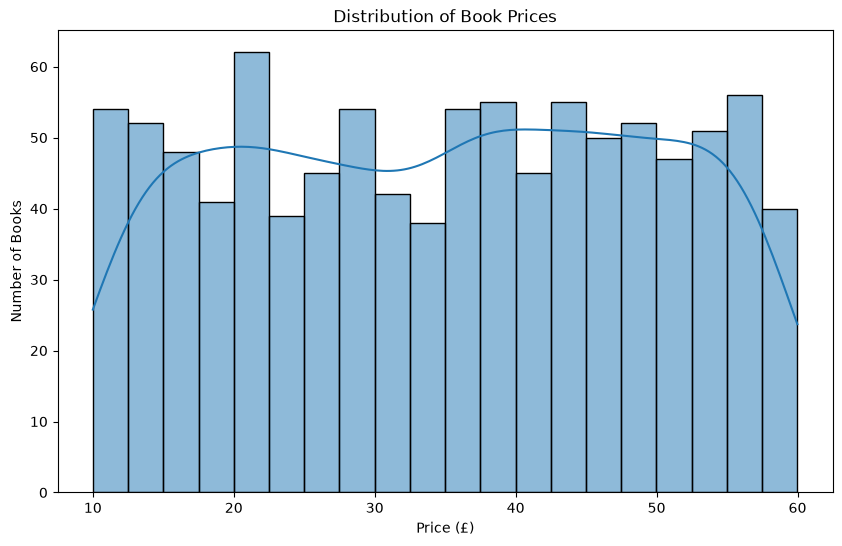

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas  as pd
# create visualization
#1. Price Distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='Price(£)',
    bins=20,
    kde=True
)

plt.title('Distribution of Book Prices')
plt.xlabel('Price (£)')
plt.ylabel('Number of Books')
plt.show()



C:\Users\LENOVO\AppData\Local\Temp\ipykernel_23732\1905529520.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


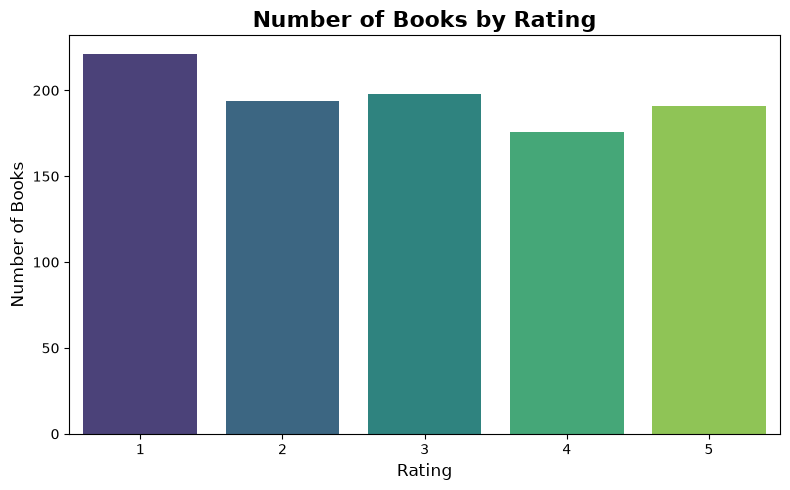

In [30]:
#2. Rating Distribution
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Rating',
    palette='viridis'
)

plt.title('Number of Books by Rating', fontsize=16, fontweight='bold')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of Books', fontsize=12)

plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_23732\437705211.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


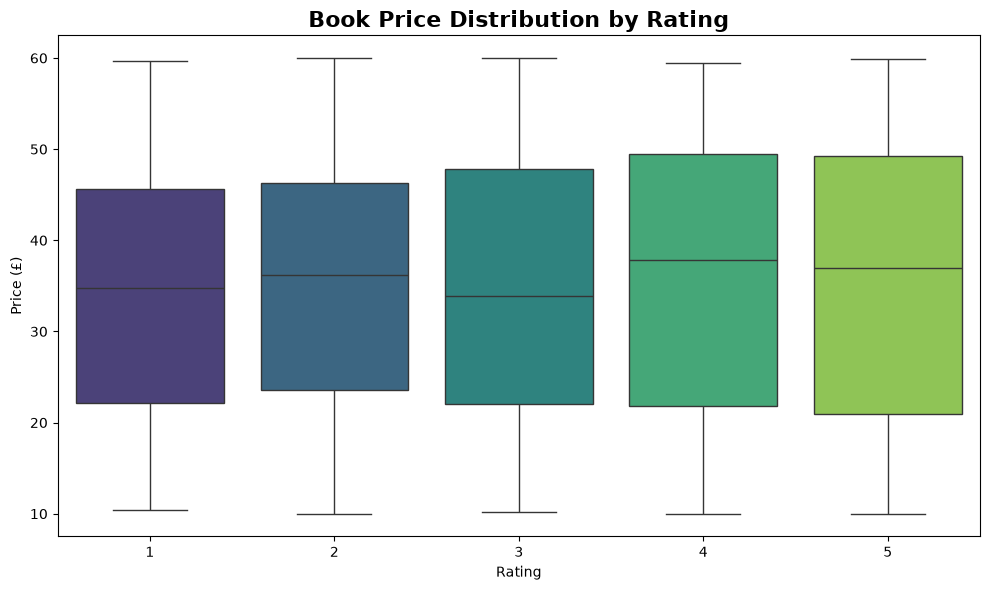

In [31]:
#3 Price vs rating
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Rating',
    y='Price(£)',
    palette='viridis'
)

plt.title('Book Price Distribution by Rating', fontsize=16, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Price (£)')

plt.tight_layout()
plt.show()

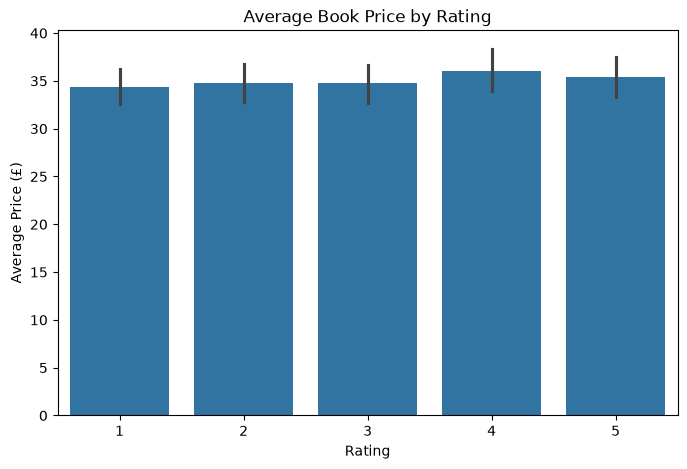

In [32]:
# 4 Average Price by Rating
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Rating',
    y='Price(£)',
    estimator='mean'
)

plt.title('Average Book Price by Rating')
plt.xlabel('Rating')
plt.ylabel('Average Price (£)')
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_23732\2508672926.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


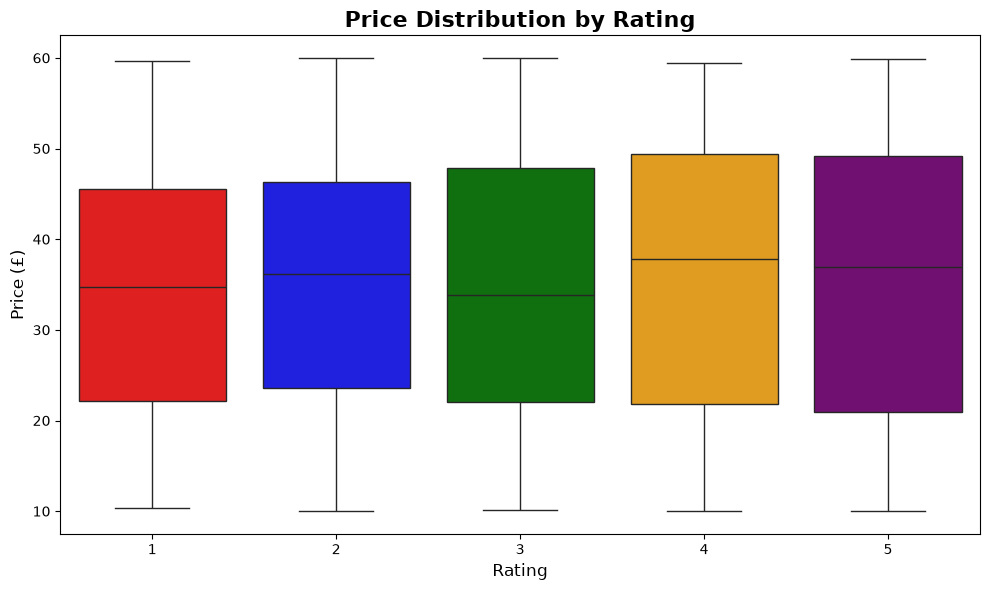

In [35]:
# 5 Rating Distribution by Price
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Rating',
    y='Price(£)',
    palette=['red', 'blue', 'green', 'orange', 'purple']
)

plt.title('Price Distribution by Rating', fontsize=16, fontweight='bold')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Price (£)', fontsize=12)

plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_23732\3439904942.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_23732\3439904942.py:4: UserWarning: The palette list has more values (4) than needed (1), which may not be intended.
  sns.countplot(


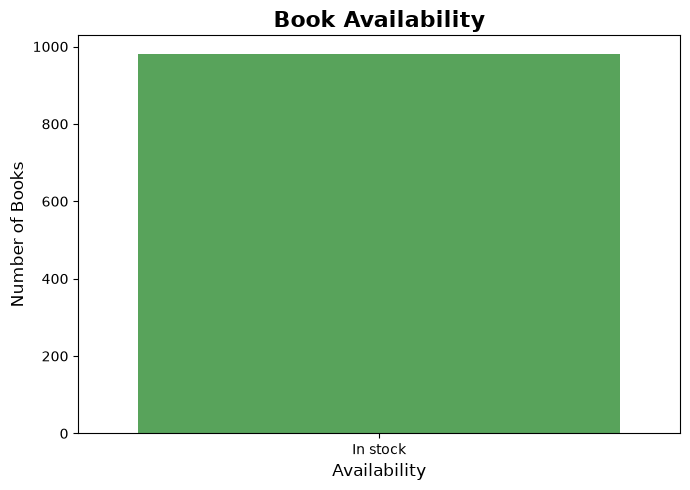

In [36]:
# Books by Availability
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Availability',
    palette=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
)

plt.title('Book Availability', fontsize=16, fontweight='bold')
plt.xlabel('Availability', fontsize=12)
plt.ylabel('Number of Books', fontsize=12)

plt.tight_layout()

plt.show()